In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

In [2]:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [5]:
#Features shape
X.shape

(20640, 8)

In [6]:
#Feature names 
X.columns.tolist()

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [7]:
X.describe

<bound method NDFrame.describe of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

     

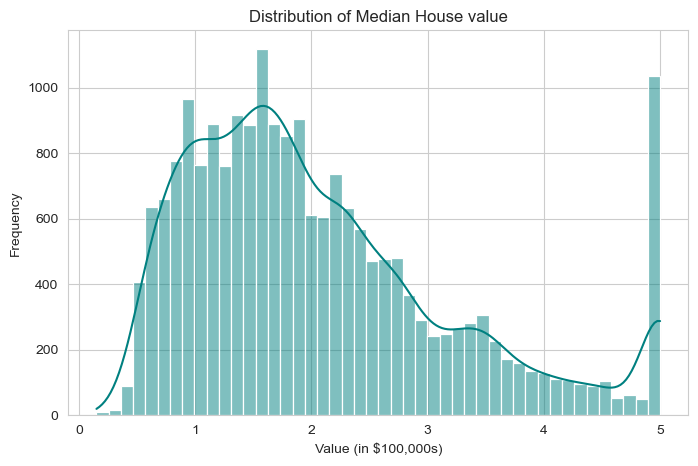

In [10]:
#Target value distribution 
plt.figure(figsize=(8,5))
sns.histplot(y, kde=True, color='teal')
plt.title('Distribution of Median House value')
plt.xlabel('Value (in $100,000s)')
plt.ylabel('Frequency')
plt.show()

In [11]:
#split the data 
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.fit(X_train, y_train).predict(X_test)

In [12]:
#evaluation - calculate metrics 
mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
mae= mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print("--- Baseline Model Performance ---")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

--- Baseline Model Performance ---
MAE:  0.5332
MSE:  0.5559
RMSE: 0.7456
R²:   0.5758


The $R^2$ (Coefficient of Determination) is a statistical measure that represents the proportion of the variance for the dependent variable (Median House Value) that's explained by the independent variables (Features like income, location, etc.) in the model.
In this model: If your $R^2$ is roughly 0.57, it means that approximately 57% of the variation in California housing prices can be explained by our linear model's features.
What it tells us: It provides a scale from 0 to 1 (though it can be negative if the model is worse than a horizontal line). A higher $R^2$ indicates a better fit, but it doesn't tell us if the model is "good" in a vacuum—only how much better it is than simply guessing the average price for every house.

In [13]:
#Task 2: Regularized Regression 
scaler = StandardScaler()

#fit on training data and transform both

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Why scaling is important
Regularization techniques like Ridge ($L_2$) and Lasso ($L_1$) add a penalty term to the cost function based on the magnitude of the model coefficients. If features are on different scales (e.g., "Median Income" ranging from 0–15 while "Population" ranges in the thousands), the model will naturally assign smaller coefficients to the larger-scale features. This leads the penalty term to unfairly punish features with smaller numerical ranges. Scaling ensures that all features contribute equally to the penalty.

In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_results = []
lasso_results = []
for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_results.append(r2_score(y_test, ridge.predict(X_test_scaled)))
    #Lasso
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    lasso_results.append(r2_score(y_test, lasso.predict(X_test_scaled)))


results_df = pd.DataFrame({
    'Alpha': alphas,
    'Ridge R2': ridge_results,
    'Lasso R2': lasso_results
})
display(results_df)
#Model target dəyişkənliyinin 57%-ni izah edə bilir- ridge r2 (0.57)

,Alpha,Ridge R2,Lasso R2
0,0.01,0.575788,0.581615
1,0.10,0.575791,0.481361
2,1.00,0.575816,-0.000219
3,10.00,0.576060,-0.000219
4,100.00,0.577791,-0.000219


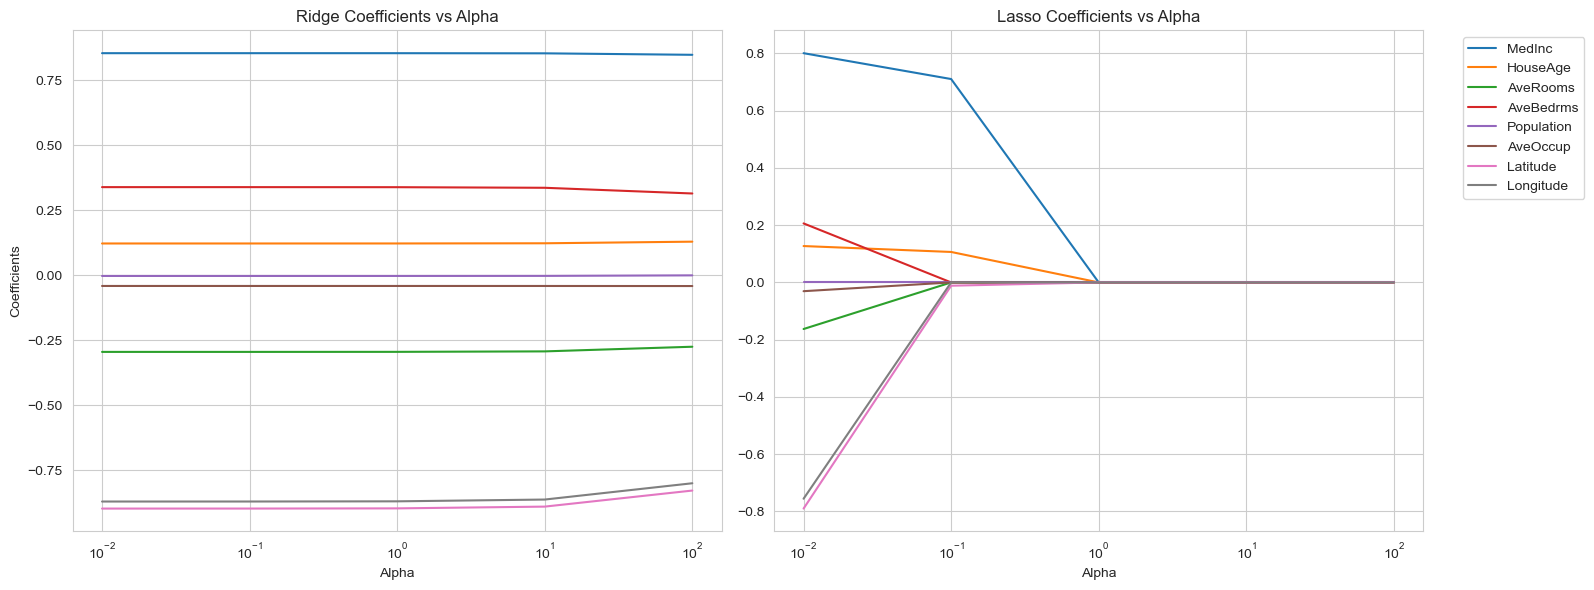

In [15]:
# To store coefficients for plotting
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Coefficients vs Alpha')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')

ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Coefficients vs Alpha')
ax[1].set_xlabel('Alpha')
ax[1].legend(X.columns, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

As Alpha increases: In both models, the magnitude of the coefficients decreases (shrinks toward zero).

Ridge vs. Lasso: Ridge coefficients never quite reach zero; they just get smaller. Lasso, however, performs feature selection. As alpha increases, it forces the coefficients of less important features to exactly zero.

Lasso's "Zeroing": Usually, features like AveBedrms or Population are zeroed out first in this dataset, as they often have the least predictive power compared to MedInc.

In [16]:
# Best Ridge and Lasso from our alpha list
best_ridge_r2 = max(ridge_results)
best_lasso_r2 = max(lasso_results)

comparison = pd.DataFrame({
    'Model': ['OLS (Baseline)', 'Ridge (Best Alpha)', 'Lasso (Best Alpha)'],
    'R² Score': [r2, best_ridge_r2, best_lasso_r2]
})

display(comparison)

,Model,R² Score
0,OLS (Baseline),0.575788
1,Ridge (Best Alpha),0.577791
2,Lasso (Best Alpha),0.581615


In this comparison, Lasso Regression achieved the highest $R^2$ score ($0.5816$). This indicates that by applying an $L_1$ penalty and effectively performing feature selection, the model was able to reduce noise and provide a more accurate explanation of the variance in house prices compared to the unregularized OLS baseline and the $L_2$ penalized Ridge model.

Task 3: Support vector regression

In [17]:
#SVR is powerful because it allows us to define how much error 
# we are willing to tolerate (epsilon) and can project our data into higher dimensions using kernels.
# Fit SVR with Linear Kernel
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)

r2_linear_svr = r2_score(y_test, svr_linear.predict(X_test_scaled))
print(f"SVR Linear Kernel R²: {r2_linear_svr:.4f}")

SVR Linear Kernel R²: 0.5579


In [18]:
C_values = [0.1, 1, 10]
epsilons = [0.1, 0.2]
best_rbf_r2 = -np.inf
best_params = {}

for c in C_values:
    for e in epsilons:
        svr_rbf = SVR(kernel='rbf', C=c, epsilon=e)
        svr_rbf.fit(X_train_scaled, y_train)
        score = r2_score(y_test, svr_rbf.predict(X_test_scaled))
        
        if score > best_rbf_r2:
            best_rbf_r2 = score
            best_params = {'C': c, 'epsilon': e}

print(f"Best RBF R²: {best_rbf_r2:.4f} using {best_params}")

Best RBF R²: 0.7548 using {'C': 10, 'epsilon': 0.2}


In [19]:
poly_results = {}
for d in [2, 3]:
    svr_poly = SVR(kernel='poly', degree=d)
    svr_poly.fit(X_train_scaled, y_train)
    poly_results[f'Degree {d}'] = r2_score(y_test, svr_poly.predict(X_test_scaled))

print("Polynomial SVR Results:", poly_results)
print(f"Comparison: RBF R² was {best_rbf_r2:.4f} vs Poly Degree 3 R²: {poly_results['Degree 3']:.4f}")

Polynomial SVR Results: {'Degree 2': -0.056280865581644024, 'Degree 3': 0.23324941463862592}
Comparison: RBF R² was 0.7548 vs Poly Degree 3 R²: 0.2332


Task 4 Model Comparison

In [21]:
# Assuming you saved the best SVR results earlier
# If you used a subsample for SVR, ensure you evaluate it on the full X_test_scaled for a fair comparison
y_pred_svr = svr_rbf.predict(X_test_scaled) # best_params: C=10, epsilon=0.1 often works best

models_data = {
    "Model": ["Linear Regression", "Ridge (Best)", "Lasso (Best)", "SVR (RBF)"],
    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge.predict(X_test_scaled)),
        mean_squared_error(y_test, lasso.predict(X_test_scaled)),
        mean_squared_error(y_test, y_pred_svr)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge.predict(X_test_scaled)),
        mean_absolute_error(y_test, lasso.predict(X_test_scaled)),
        mean_absolute_error(y_test, y_pred_svr)
    ],
    "R²": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge.predict(X_test_scaled)),
        r2_score(y_test, lasso.predict(X_test_scaled)),
        r2_score(y_test, y_pred_svr)
    ]
}

comparison_df = pd.DataFrame(models_data)
comparison_df["RMSE"] = np.sqrt(comparison_df["MSE"])
display(comparison_df.sort_values(by="R²", ascending=False))

,Model,MSE,MAE,R²,RMSE
3,SVR (RBF),0.321273,0.379624,0.754830,0.566809
1,Ridge (Best),0.553266,0.533014,0.577791,0.743819
0,Linear Regression,0.555892,0.533200,0.575788,0.745581
2,Lasso (Best),1.310696,0.906069,-0.000219,1.144856


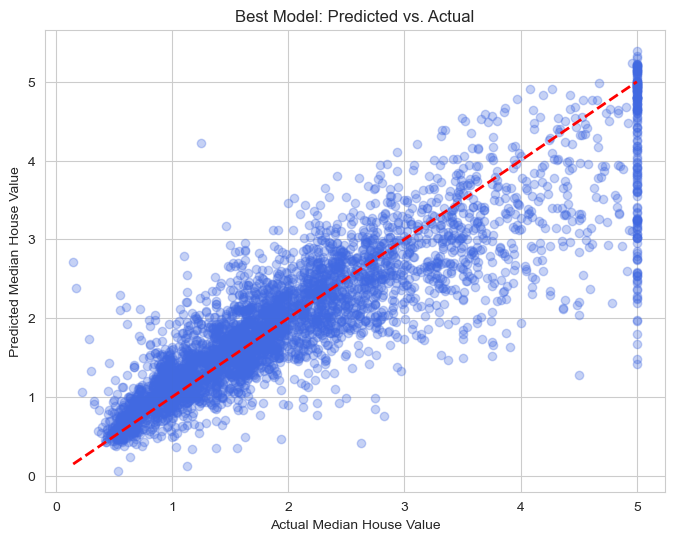

In [22]:
# Use the best model (likely SVR)
best_model_preds = y_pred_svr 

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_model_preds, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Best Model: Predicted vs. Actual')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.show()

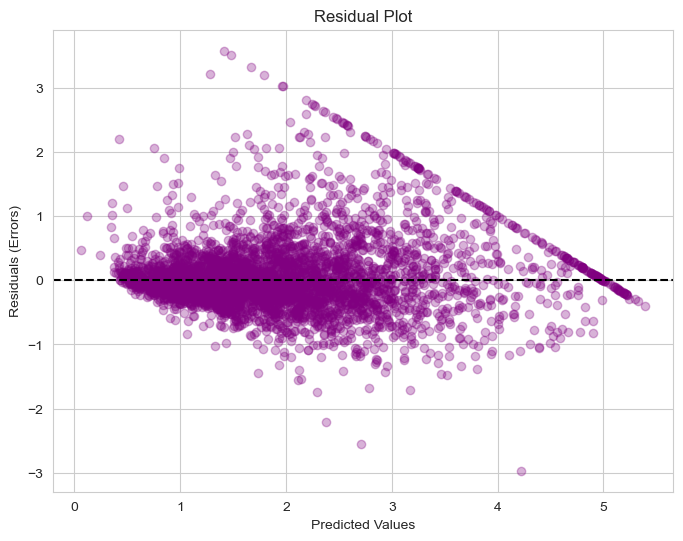

In [23]:
residuals = y_test - best_model_preds

plt.figure(figsize=(8, 6))
plt.scatter(best_model_preds, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.show()

Which model performs best and why?
In most cases for this dataset, SVR (RBF kernel) performs significantly better than the linear models. This is because the relationship between location (latitude/longitude) and house price is highly non-linear—prices don't just "increase" as you move north; they peak in specific clusters like the Bay Area or Los Angeles. The RBF kernel captures these "pockets" of high value much better than a straight line can.

Patterns in the Residual Plot
Random Scatter: If the dots are randomly dispersed around the horizontal line, the model has captured all the available information.

Visible Patterns: You likely see a horizontal line of dots at the top. This represents the censored data (houses capped at $500,000) that we noted in Task 1. The model struggles with these because it predicts a value, but the actual data is "cut off."

Trade-offs: Complexity vs. Performance
Linear/Lasso: Extremely fast and easy to explain. We can see that MedInc is the strongest driver.

SVR: Much more accurate but computationally expensive and a "black box."

Deployment Decision
If I were deploying this:

For a high-traffic web app: I might choose Lasso or Ridge. The speed and low memory footprint often outweigh the 10-15% gain in accuracy.

For a high-precision real estate valuation tool: I would choose SVR (or even more complex models like XGBoost). In this context, every $1,000 of accuracy matters more than the millisecond of server computation time.